Plot SOLPS balance file

In [1]:
##### %matplotlib widget


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib, shlex, subprocess
import xbout
import scipy
import netCDF4 

import xhermes
from xhermes import *
sys.path.append(r"/users/jpm590/2dspace/post-processing/sdtools/")
from code_comparison.solps_pp import *
from hermes3.case_db import *
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
%load_ext autoreload
%autoreload 2
print("Loaded")


Loaded


#### Check variables by reading netcdf

In [2]:
## Checkv variables by netcdf
filepath = "./balance.nc"
nc = netCDF4.Dataset(filepath)
list(nc.variables.keys() )
key = "pr"
if key in nc.variables.keys():
    print(key)
    print(nc[key])
else:
    print("Not found")


Not found


## Read SOLPS by solps_pp and read hermes-3

In [4]:
# Read SOLPS
bal = SOLPScase(".")
print(type(bal))

# Read Hermes-3
db = CaseDB(
    case_dir = r"/users/jpm590/scratch/",
    grid_dir = r"/users/jpm590/neutralrun/hermes-3/master"

)
toload = [
    dict(name="nowallpump_1e21_limiterOFF", id="260217-cdn-46895-nowallpump_limiterOff_1e21", unnormalise_geom = True, use_xhermes = True, squash = True),   

]
cs = {}
for case in toload:
    cs[case["name"]] = db.load_case_2D(case["id"], use_squash = case["squash"], verbose = True)

    cs[case["name"]].extract_2d_tokamak_geometry()

<class 'code_comparison.solps_pp.SOLPScase'>
- Reading case 260217-cdn-46895-nowallpump_limiterOff_1e21
-----------------------
- Looking for squash file


/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/boutdata/data.py:765: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: [Errno 2] No such file or directory: '"CDN_46895_260129_nowallpump_1e21.nc"'
Evaluating non-scalar options not available
  alwayswarn(


- Squash file found. squash date 02/23/2026, 23:35:19, dmp file date 02/23/2026, 23:17:54


/users/jpm590/workspace/hermes-3/venv/lib/python3.12/site-packages/xbout/load.py:1129: UserWarning: Will drop all variables containing the dimensions 'closed_wall' because they are not recognised
  warn(



Unnormalising with xHermes


## Polygon for solps

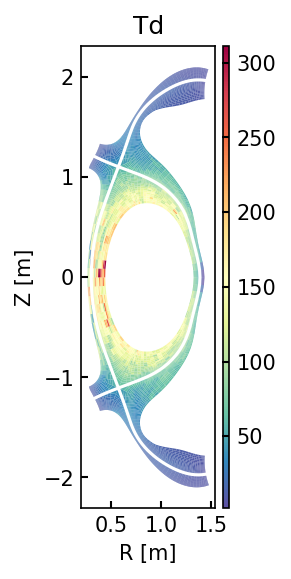

In [13]:
bal.plot_2d("Td")

## Check some number between the two

In [22]:
# SOLPS
df = bal.get_1d_radial_data(params=["Td+","Nd+","Te","Ne",], region="omp")


# Hermes-3 
print("\n" + "="*50)
print("Hermes-3 Parameters")
print("="*50)

ds = cs["nowallpump_1e21_limiterOFF"].ds.isel(t=-1)

nparticle = (ds["Nd+"].values +
             ds["Nd"].values +
             ds["Ne"].values) * ds["dv"].values
nparticles = np.sum(nparticle)
nion= (ds["Nd+"].values  * ds["dv"].values)
nions = np.sum(nion)
ne= (ds["Ne"].values  * ds["dv"].values)
nes = np.sum(ne)

puff_rate = np.sum(ds["Sd_src"].values * ds["dv"].values)

extra_particles = nparticles - puff_rate

recycled_neutral = np.sum(
    ds["Sd_target_recycle"].values * ds["dv"].values
)
# print(ds["Sd_target_recycle"].values)
recomb = np.sum(
    ds["Sd+_rec"].values * ds["dv"].values
)
iz = np.sum(
    ds["Sd+_iz"].values * ds["dv"].values
)
ext_ion_src = np.sum(
    ds["Sd+_src"].values * ds["dv"].values
)

print(f"{'Total particles:':30s} {nparticles:15.6e}")
print(f"{'Total ions:':30s} {nions:15.6e}")
print(f"{'Total electrons:':30s} {nes:15.6e}")

print(f"{'Puff rate (Sd_src):':30s} {puff_rate:15.6e}")
print(f"{'Extra particles:':30s} {extra_particles:15.6e}")
print("-"*50)
print(f"{'Expected ion lost (1%):':30s} {puff_rate*0.01:15.6e}")
print(f"{'Expected n recycled (99%):':30s} {puff_rate*0.99:15.6e}")
print(f"{'Actual recycled neutrals:':30s} {recycled_neutral:15.6e}")
print("-"*50)
print("Total sink of ions")
#original ion flux into target recycled_neutral/0.99
lost_ion = recycled_neutral/0.99*0.01
print(f"{'Sd+_rec:':30s} {recomb:15.6e}")
print(f"{'ion lost:':30s} {lost_ion:15.6e}")

print("Total source of ions")
print(f"{'Sd+_iz:':30s} {iz:15.6e}")

# print(f"external ions {'Sd+_src':30s} {ext_ion_src:15.6e}")


print("="*50)



Hermes-3 Parameters
Total particles:                  1.210552e+21
Total ions:                       2.379774e+20
Total electrons:                  2.379774e+20
Puff rate (Sd_src):               1.000000e+21
Extra particles:                  2.105518e+20
--------------------------------------------------
Expected ion lost (1%):           1.000000e+19
Expected n recycled (99%):        9.900000e+20
Actual recycled neutrals:         1.018745e+23
--------------------------------------------------
Total sink of ions
Sd+_rec:                         -9.005868e+26
ion lost:                         1.029035e+21
Total source of ions
Sd+_iz:                           2.378224e+29


,dist,sep,apar,vol,Td+,Nd+,Pd+
1,-0.059120,0,0.032928,0.004145,337.633017,5.219288e+18,282.336208
2,-0.051964,0,0.030077,0.003819,319.208769,5.002481e+18,255.841275
3,-0.045477,0,0.027357,0.003503,302.060232,4.798609e+18,232.230538
4,-0.039615,0,0.024775,0.003198,286.156565,4.606932e+18,211.215581
5,-0.034336,0,0.022338,0.002906,271.439200,4.427417e+18,192.545525
6,-0.029600,0,0.020051,0.002628,257.857499,4.259874e+18,175.989568
7,-0.025366,0,0.017921,0.002365,245.377232,4.103842e+18,161.337488
8,-0.021596,0,0.015952,0.002119,233.946906,3.958887e+18,148.388677
9,-0.018250,0,0.014149,0.001891,223.505038,3.824578e+18,136.956062
10,-0.015289,0,0.012516,0.001681,214.004241,3.700687e+18,126.886405


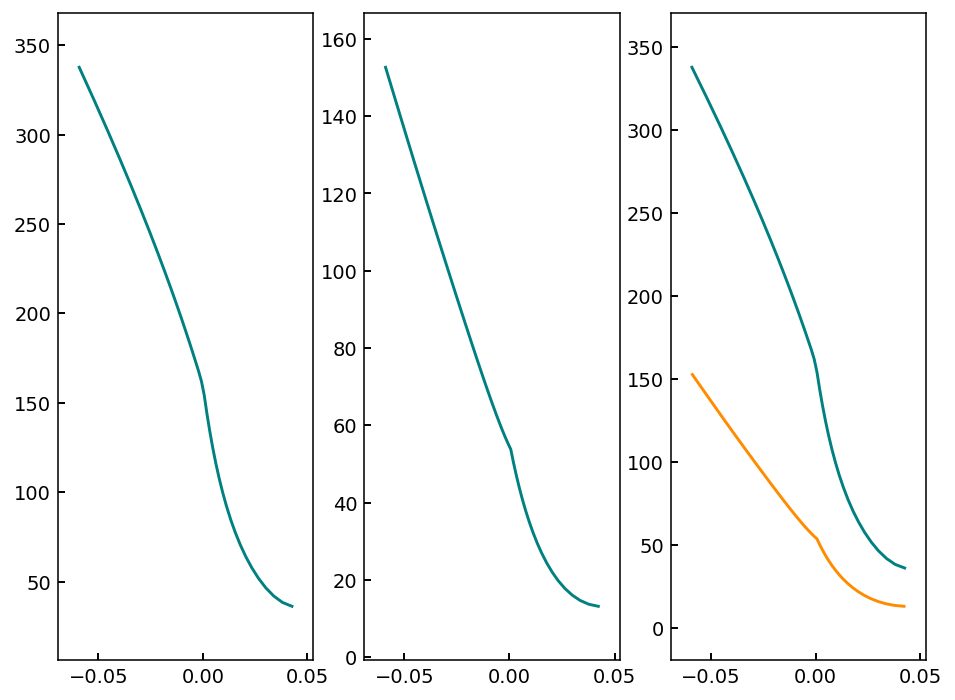

In [4]:

# list(bal.variables.keys())
# get_1d_radial_data is a pandas dataframe
df = bal.get_1d_radial_data(params=["Td+","Nd+","Pd+"], region="omp")
display(df)

fig, ax = plt.subplots(1,3, figsize = (8, 6))
ax[0].plot(df["dist"], df["Td+"])

## Hermes-3
ds = cs["nowallpump_1e21_limiterOFF"].ds.isel(t=-1)


df_hermes = get_1d_radial_data(ds, params = ["Td+"], region = "omp")
ax[1].plot(df_hermes["Srad"], df_hermes["Td+"])

ax[2].plot(df["dist"], df["Td+"])
ax[2].plot(df_hermes["Srad"], df_hermes["Td+"])



,R,Z,Spol,Te,Ne,Pe,Spar,apar,region,Xpoint
0,1.386883,0.000000,0.000000,55.209496,3.003276e+18,26.565589,0.000000,0.005992,upstream,0
1,1.386883,-0.036295,0.035968,55.209502,3.003057e+18,26.563649,0.069251,0.005992,upstream,0
2,1.379287,-0.108387,0.107968,55.207556,2.984253e+18,26.396392,0.204954,0.005911,upstream,0
3,1.365861,-0.179362,0.179892,55.203478,2.963601e+18,26.211787,0.337044,0.005793,upstream,0
4,1.349616,-0.249263,0.251442,55.197037,2.945573e+18,26.049290,0.467518,0.005706,upstream,0
...,...,...,...,...,...,...,...,...,...,...
62,1.417374,-1.960725,2.679222,10.924301,1.148184e+19,20.096266,17.817318,0.007120,divertor,0
63,1.428768,-1.959382,2.689175,10.781718,1.087664e+19,18.788552,17.904175,0.007176,divertor,0
64,1.437132,-1.958190,2.696041,10.700933,9.862804e+18,16.909565,17.963459,0.007217,divertor,0
65,1.442331,-1.957359,2.699658,10.663170,8.264046e+18,14.118530,17.994481,0.007243,divertor,0


Pe is 66    14.021058
65    14.099349
64    16.886593
63    18.763027
62    20.068964
        ...    
4     26.013901
3     26.176177
2     26.360532
1     26.527562
0     26.529499
Length: 67, dtype: float64
Hermes-3 Pe is 65     1.215040
64     1.568278
63     1.986700
62     2.446163
61     2.927066
        ...    
4     56.471858
3     56.477309
2     56.488238
1     56.496774
0     56.496808
Length: 66, dtype: float64


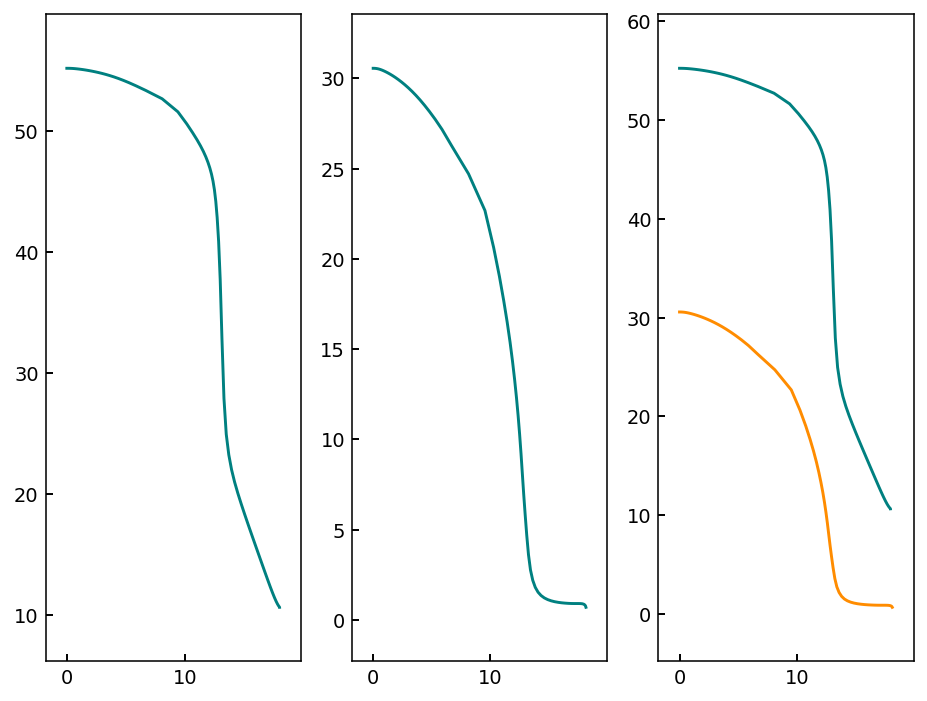

In [9]:
df = bal.get_1d_poloidal_data(params=["Te","Ne","Pe"], region="outer_lower",sepadd=1)
display(df)
qe = 1.6e-19

print(f"Pe is {df["Te"][::-1]*df["Ne"][::-1]*qe}")
fig, ax = plt.subplots(1,3, figsize = (8, 6))
ax[0].plot(df["Spar"], df["Te"])
# # Hermes-3

ds = cs["nowallpump_1e21_limiterOFF"].ds.isel(t=-1)


df_hermes = get_1d_poloidal_data(ds, params = ["Te","Ne"], region = "outer_lower",sepadd =1 )

print(f"Hermes-3 Pe is {df_hermes["Te"][::-1]*df_hermes["Ne"][::-1]*qe}")
ax[1].plot(df_hermes["Spar"], df_hermes["Te"])

ax[2].plot(df["Spar"], df["Te"])
ax[2].plot(df_hermes["Spar"], df_hermes["Te"])

In [ ]:
fig, ax = plt.subplots()
bal.plot_separatrix(ax=ax, ls = "-", c="red")
ax.set_aspect('equal', adjustable='box')


In [ ]:
fig, ax = plt.subplots()

bal.plot_2d(ax=ax, param="Te")

ax.set_aspect('equal', adjustable='box')


In [ ]:
bal.plot_selection(outer)